# Sentiment Analysis for Film Reviews
**A Binary Classification Project**

Film Junky Union, an avant-garde community for classic film enthusiasts, is developing a system to filter and categorize movie reviews. The project's objective is to train a model that automatically detects negative reviews. Using an IMDB movie review dataset with polarity labels, the goal is to build a classification model that distinguishes between positive and negative reviews. The model must achieve an F1 score of at least 0.85.

## Overview

In [54]:
# Data manipulation and analisis
import math
import numpy as np
import pandas as pd

# Visualization
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

# Vectorizing and normalizing
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import torch
import transformers

In [2]:
# Cuality configuration
%matplotlib inline
%config InlineBackend.figure_format = 'png'
%config InlineBackend.figure_format = 'retina'

tqdm.pandas()

## Initial Exploration and Cleaning

In [3]:
df_reviews = pd.read_csv('/Users/Rosella/Downloads/Triple Ten Projects/movie-reviews-sentinent-analysis/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [4]:
df_reviews.head()

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


In [5]:
# Checking nulls
print(df_reviews.isnull().sum())

# Filling nulls
rating_median = df_reviews['average_rating'].dropna().median()
df_reviews.fillna({'average_rating': rating_median}, inplace=True)
df_reviews.fillna({'votes': 0}, inplace=True)

# Checking duplicates
print('\nDuplicates:', df_reviews.duplicated().sum())

# Changing data types
df_reviews['end_year'] = df_reviews['end_year'].replace('\\N', np.nan)
df_reviews['end_year'] = pd.to_numeric(df_reviews['end_year'], errors='coerce')

df_reviews['runtime_minutes'] = df_reviews['runtime_minutes'].replace('\\N', np.nan)
df_reviews['runtime_minutes'] = pd.to_numeric(df_reviews['runtime_minutes'], errors='coerce')

runtime_median = df_reviews['runtime_minutes'].dropna().median()
df_reviews.fillna({'runtime_minutes': runtime_median}, inplace=True)

print(f"Data types: {df_reviews['end_year'].dtype}")
print(f"Data types: {df_reviews['runtime_minutes'].dtype}")

tconst             0
title_type         0
primary_title      0
original_title     0
start_year         0
end_year           0
runtime_minutes    0
is_adult           0
genres             0
average_rating     2
votes              2
review             0
rating             0
sp                 0
pos                0
ds_part            0
idx                0
dtype: int64

Duplicates: 0
Data types: float64
Data types: float64


## EDA

**Number of movies and reviews along the years**

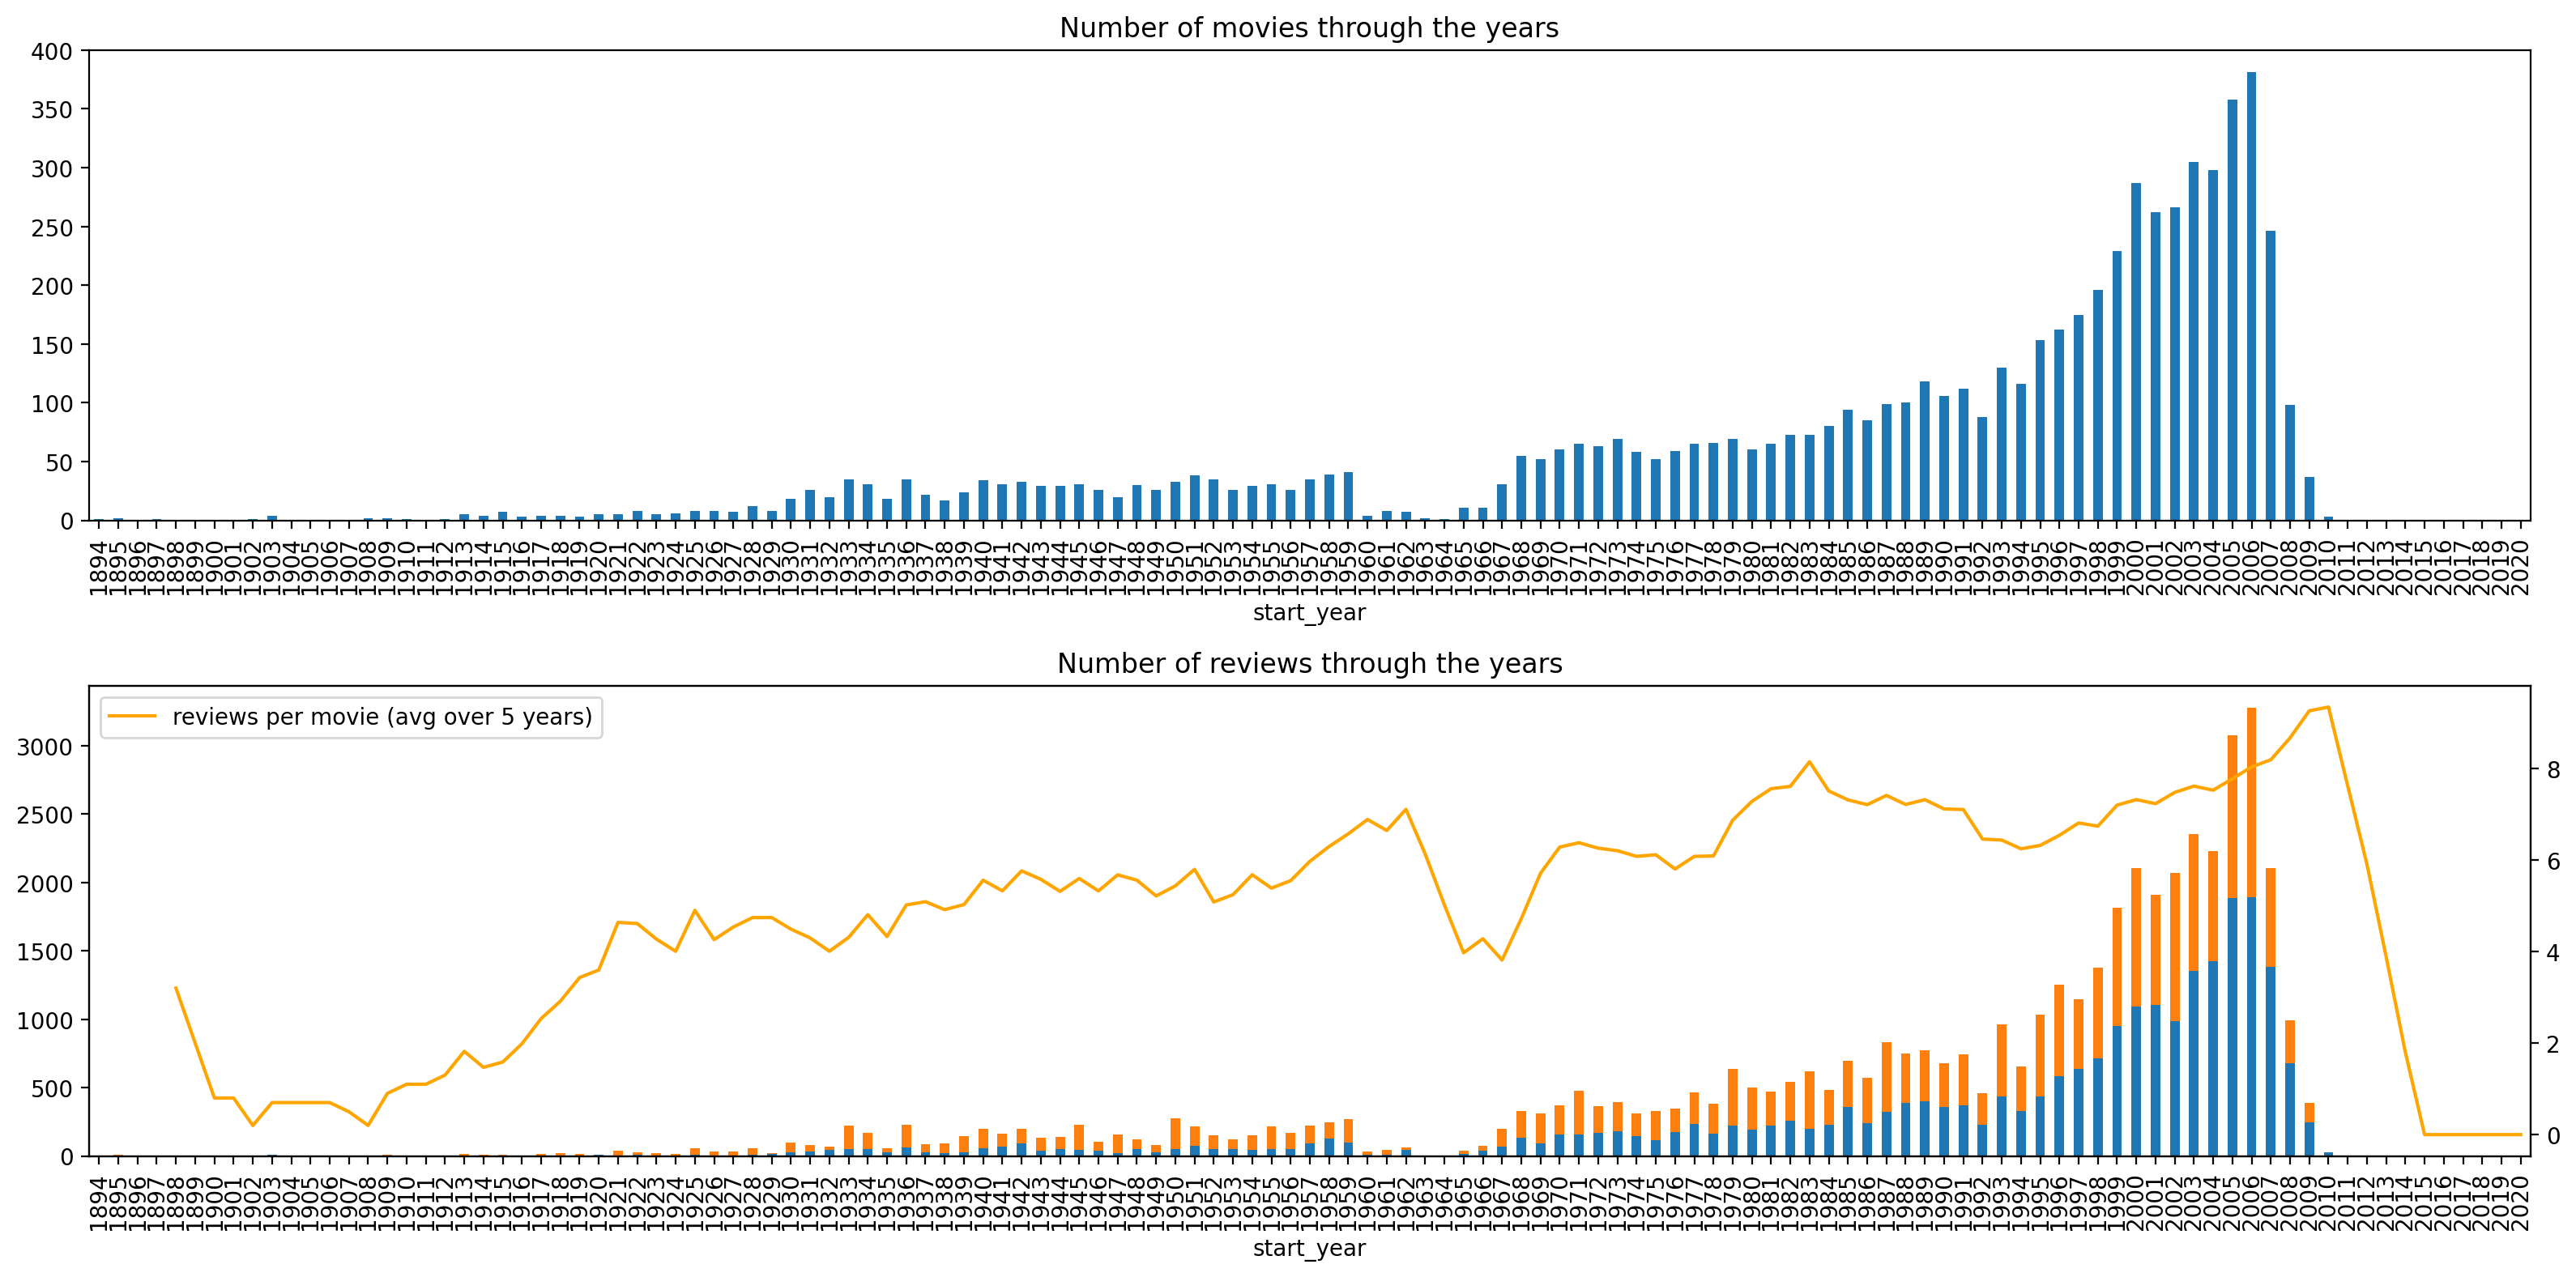

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of movies through the years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of reviews through the years')

fig.tight_layout()

The analysis reveals a clear temporal correlation: the 2000-2007 period recorded both the peak in film production and the highest volume of reviews. This demonstrates that content availability directly drives audience engagement, where more films create more opportunities for users to express opinions and ratings, particularly when the content resonates with the audience.

**Distribution of the number of reviews per movie with numbers and KDE**

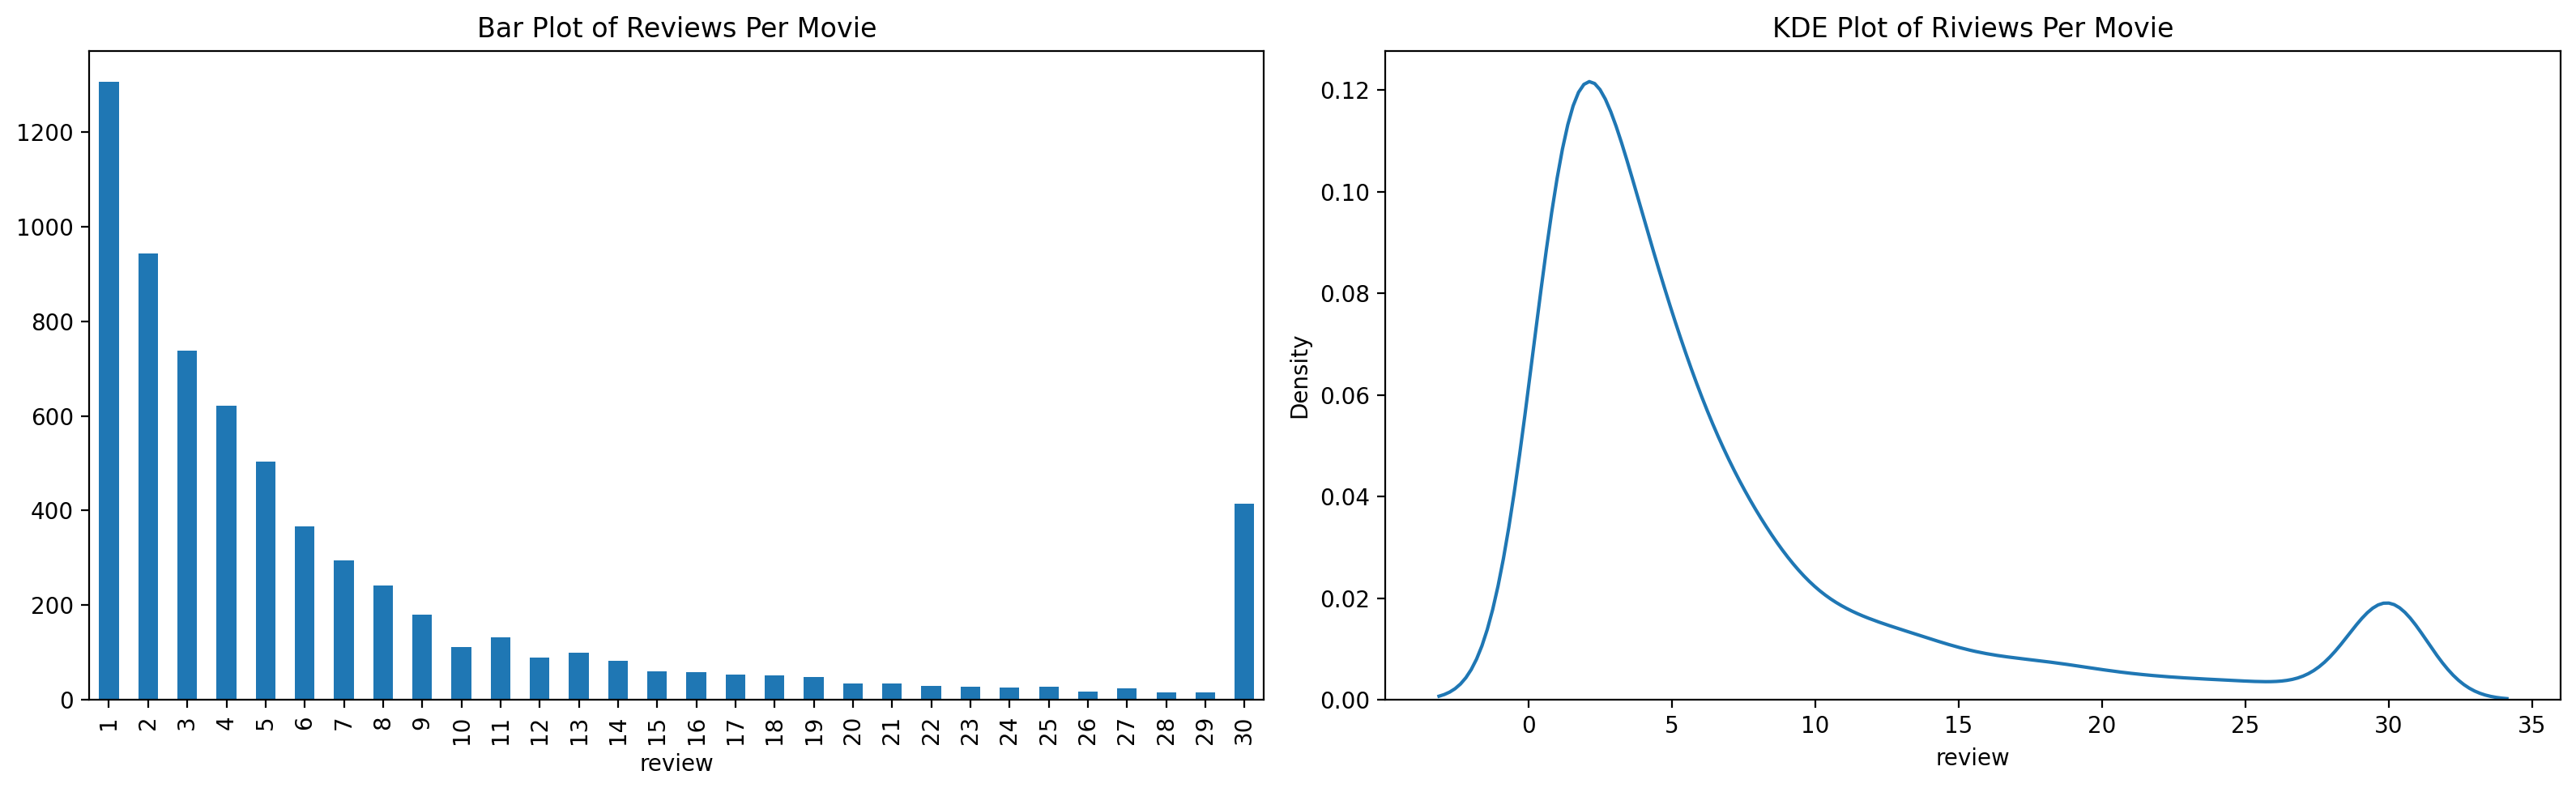

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of Riviews Per Movie')

fig.tight_layout()

The distribution of reviews per film follows a typical concentration pattern: the vast majority of movies receive very few reviews, while a limited number of films capture most of the interaction. This reflects the common phenomenon where a small number of viral or popular contents attract massive public attention, leaving the remainder with marginal participation.

In [21]:
df_reviews['pos'].value_counts()

pos
0    23715
1    23616
Name: count, dtype: int64

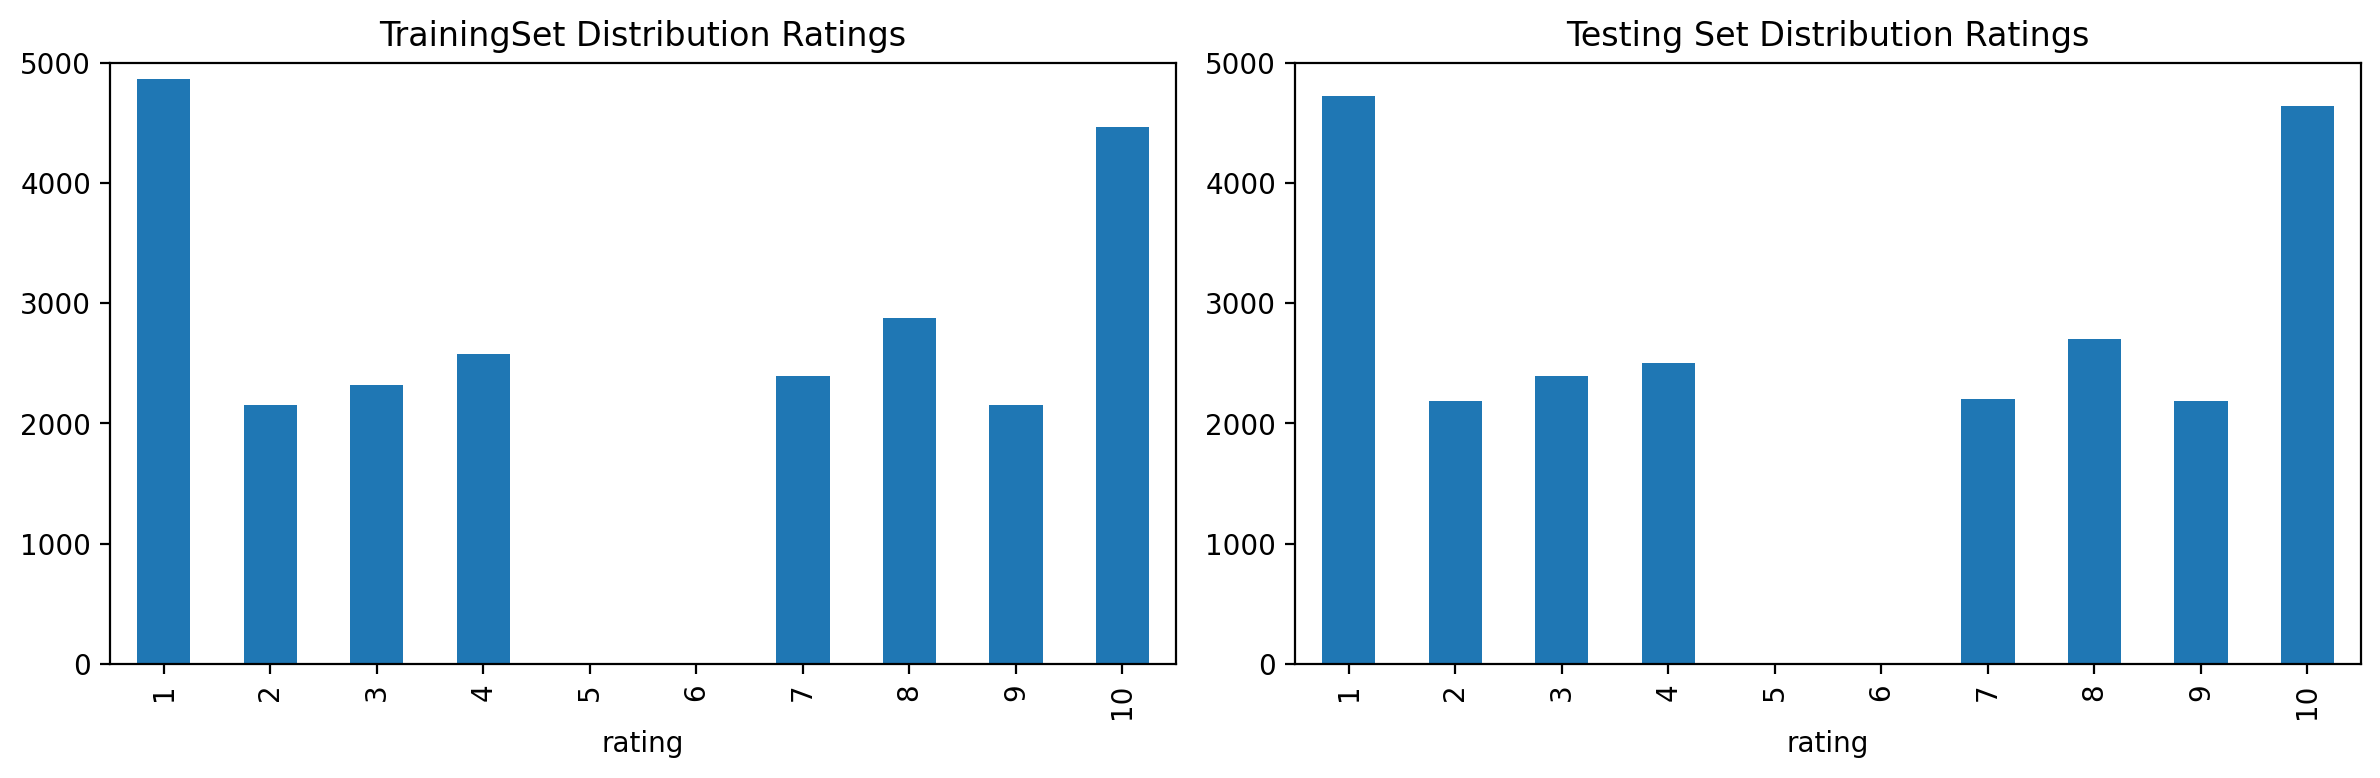

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('TrainingSet Distribution Ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('Testing Set Distribution Ratings')

fig.tight_layout()

Both training and test sets show nearly identical distributions, indicating a balanced and representative split. The most frequent ratings are 7, 8, and 10, with rating 7 being predominant at approximately 4,500 reviews in each set. In contrast, extreme ratings (1, 2, and 9) are the least common, with only around 1,000 reviews each. This similarity between sets ensures the model trains and evaluates on data reflecting the same real-world preference distribution.

**Positive and negative reviews distribution through the years in training and testing dataset**

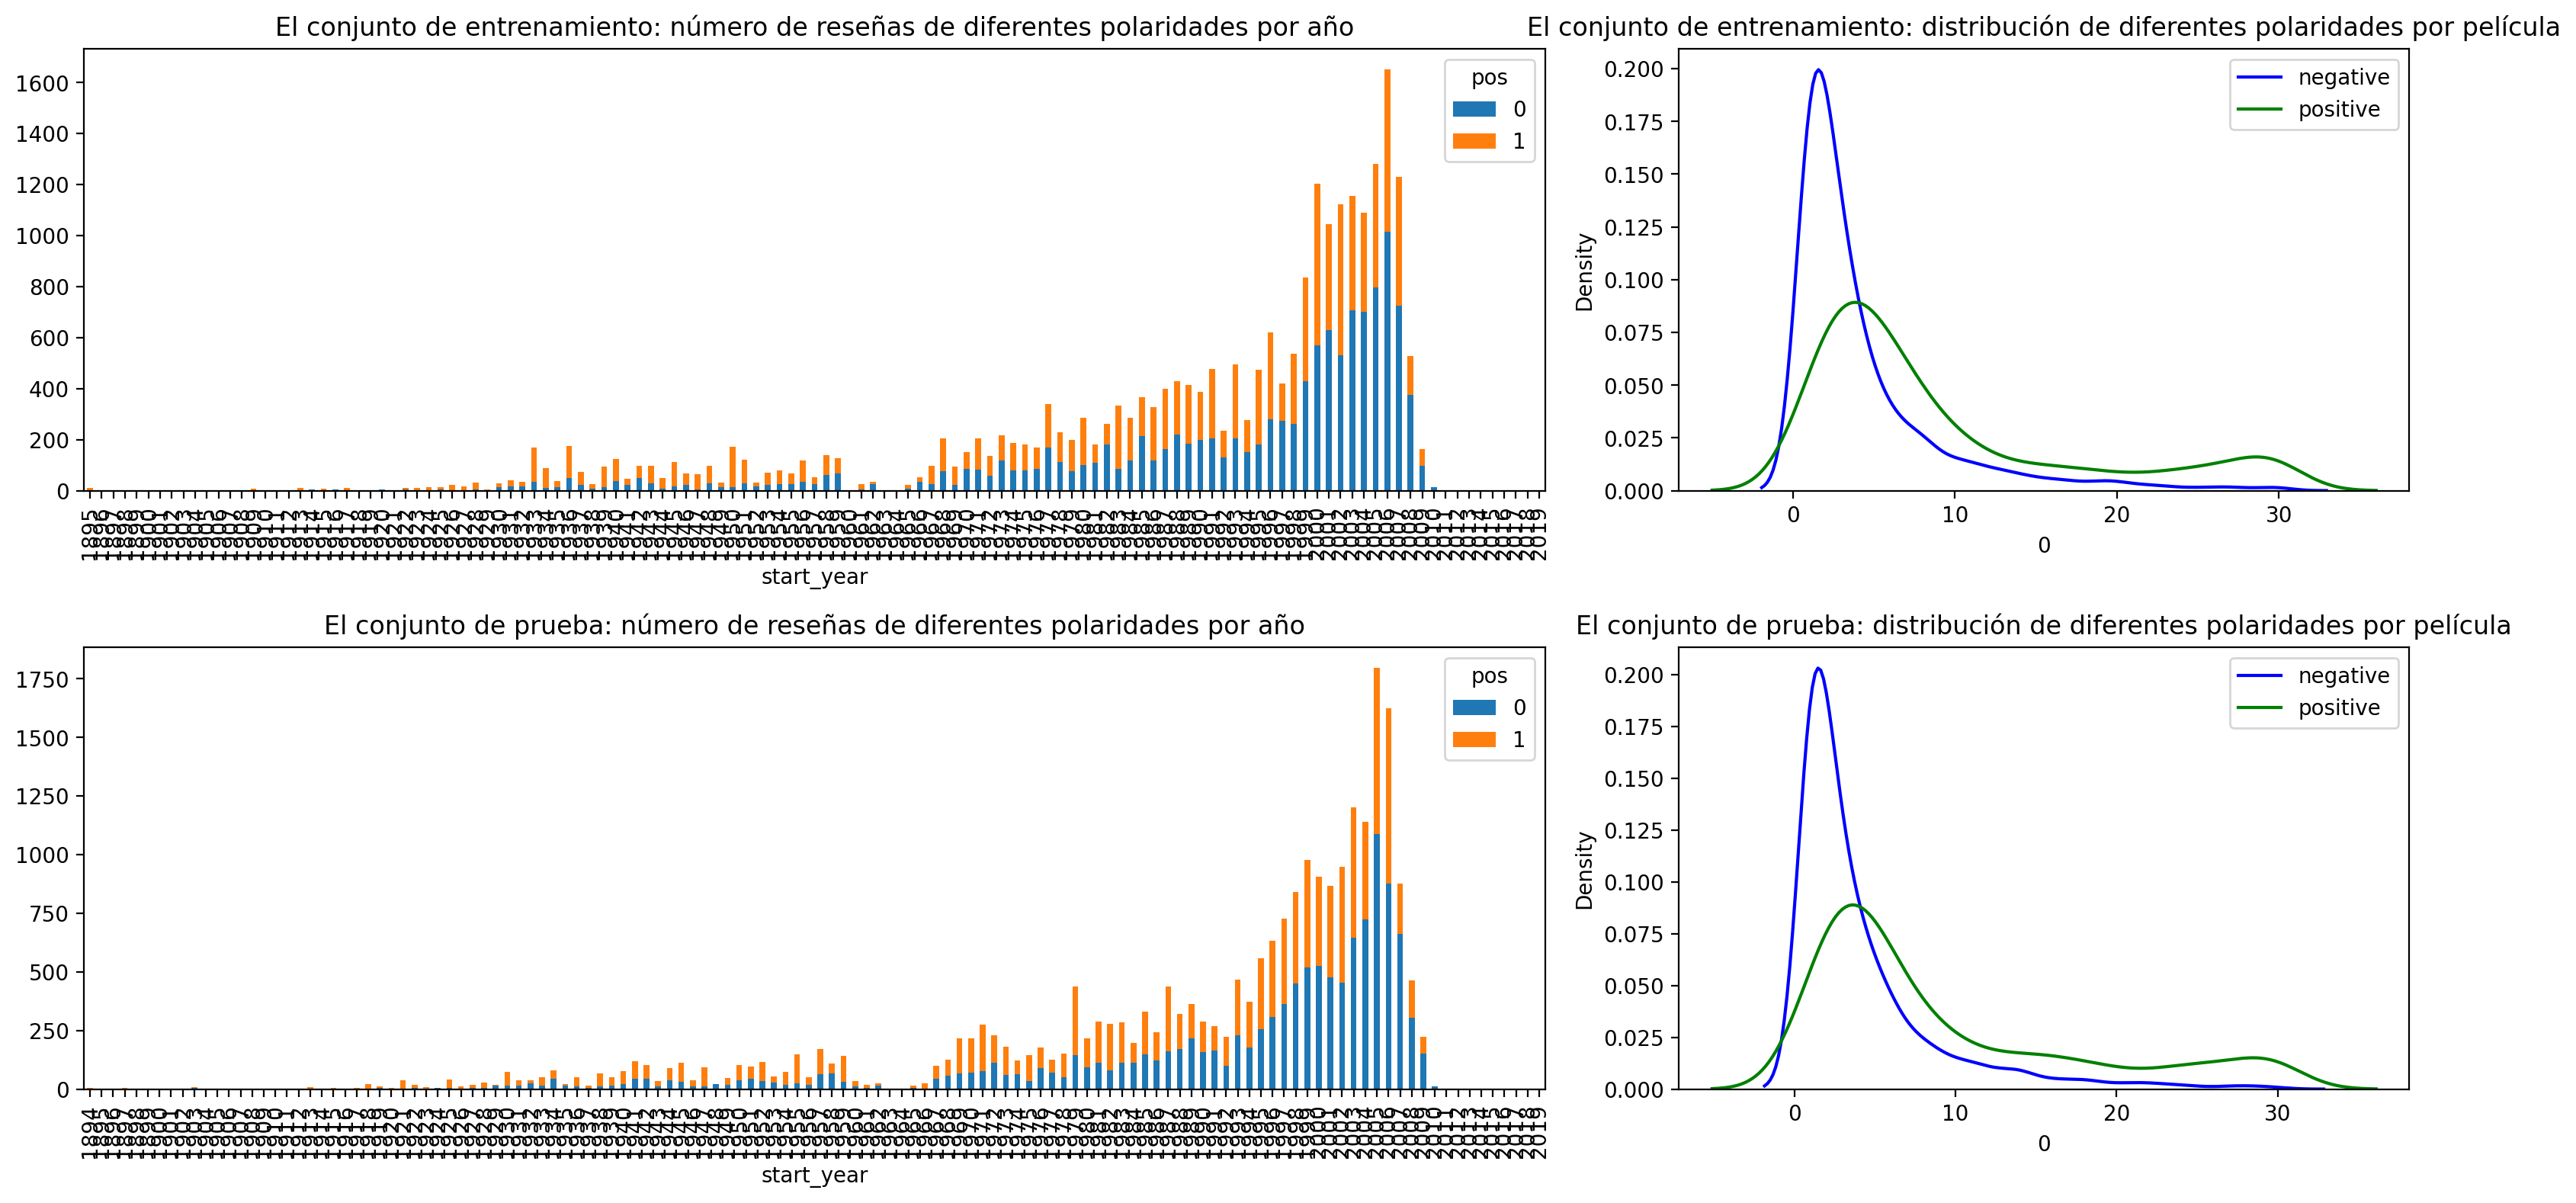

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('El conjunto de entrenamiento: número de reseñas de diferentes polaridades por año')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', ax=ax)  # Removed kernel='epa'
sns.kdeplot(dft[1], color='green', label='positive', ax=ax)  # Removed kernel='epa'
ax.legend()
ax.set_title('El conjunto de entrenamiento: distribución de diferentes polaridades por película')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('El conjunto de prueba: número de reseñas de diferentes polaridades por año')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', ax=ax)  # Removed kernel='epa'
sns.kdeplot(dft[1], color='green', label='positive', ax=ax)  # Removed kernel='epa'
ax.legend()
ax.set_title('El conjunto de prueba: distribución de diferentes polaridades por película')

fig.tight_layout()

The charts reveal consistent patterns between training and test sets. The temporal distribution shows similar evolution in the proportion of positive and negative reviews across years, with activity peaks occurring in matching periods. The KDE plots demonstrate that most films concentrate few reviews of both polarities, forming sharp peaks near zero, while a minority of movies accumulates significantly higher volumes.

**Class Inbalance**

In [10]:
# Ratings distribution
rating_dist = df_reviews['rating'].value_counts().sort_index(ascending=True)
print('Ratings Distribution:')
print(rating_dist)
print(f"\nMax: {rating_dist.max()}, min: {rating_dist.min()}")

# Inbalance of polarities
pol_dist = df_reviews['pos'].value_counts()
print(f"Ratio between classes: {pol_dist.max()/pol_dist.min()}")


Ratings Distribution:
rating
1     9589
2     4339
3     4709
4     5078
7     4593
8     5576
9     4343
10    9104
Name: count, dtype: int64

Max: 9589, min: 4339
Ratio between classes: 1.0041920731707317


The rating distribution reveals moderate imbalance in the dataset. Rating 1 is the most frequent with 9,589 reviews, while rating 9 shows the lowest frequency with 4,339 reviews, resulting in a 2.2x imbalance ratio between majority and minority classes.

Regarding polarity (positive/negative), the balance is nearly perfect with a 1.004 ratio, indicating almost equal proportions between positive and negative reviews.

## Evaluation Process

In [19]:
import sklearn.metrics as metrics
def evaluate_model(model, X_train, y_train, X_test, y_test):

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Probabilities for AUC
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Calculating key metrics
    metrics_dict = {
        'Train': {
            'Accuracy': metrics.accuracy_score(y_train, y_train_pred),
            'F1': metrics.f1_score(y_train, y_train_pred),
            'ROC AUC': metrics.roc_auc_score(y_train, y_train_proba)
        },
        'Test': {
            'Accuracy': metrics.accuracy_score(y_test, y_test_pred),
            'F1': metrics.f1_score(y_test, y_test_pred),
            'ROC AUC': metrics.roc_auc_score(y_test, y_test_proba)
        }
    }

    # Display results
    df_metrics = pd.DataFrame(metrics_dict).round(3)
    print("Model Performance Metrics:")
    print(df_metrics)

    # ROC curve
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    fpr_train, tpr_train, _ = metrics.roc_curve(y_train, y_train_proba)
    fpr_test, tpr_test, _ = metrics.roc_curve(y_test, y_test_proba)
    
    plt.plot(fpr_train, tpr_train, label=f'Train (AUC = {metrics_dict["Train"]["ROC AUC"]:.3f})')
    plt.plot(fpr_test, tpr_test, label=f'Test (AUC = {metrics_dict["Test"]["ROC AUC"]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()

    # Confusion Matrix
    plt.subplot(1, 2, 2)
    cm = metrics.confusion_matrix(y_test, y_test_pred)
    metrics.ConfusionMatrixDisplay(cm).plot(ax=plt.gca())
    plt.title('Confusion Matrix (Test Set)')
    
    plt.tight_layout()
    plt.show()
    
    return

## Normalizing

In [14]:
def simple_preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    # Filtrar stopwords y palabras cortas
    words = [word for word in words if word not in ENGLISH_STOP_WORDS and len(word) > 2]
    return " ".join(words)

df_reviews['review_norm'] = df_reviews['review'].apply(simple_preprocess)


## Dividing Dataset Training / Testing

In [15]:
X_train = df_reviews.query('ds_part == "train"').copy()
X_test = df_reviews.query('ds_part == "test"').copy()

y_train = X_train['pos']
y_test = X_test['pos']

print(X_train.shape)
print(X_test.shape)

(23796, 18)
(23535, 18)


## Vectorizing

In [56]:
# TF-IDF
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.7
)

X_tfidf_train = tfidf.fit_transform(X_train['review_norm'])
X_tfidf_test = tfidf.transform(X_test['review_norm'])


print(f"TF-IDF train shape: {X_tfidf_train.shape}")
print(f"TF-IDF test shape: {X_tfidf_test.shape}")

TF-IDF train shape: (23796, 8000)
TF-IDF test shape: (23535, 8000)


## Model Training

### Modelo 0 - Dummy

Model Performance Metrics:
          Train   Test
Accuracy    0.5  0.501
F1          0.5  0.501
ROC AUC     0.5  0.501


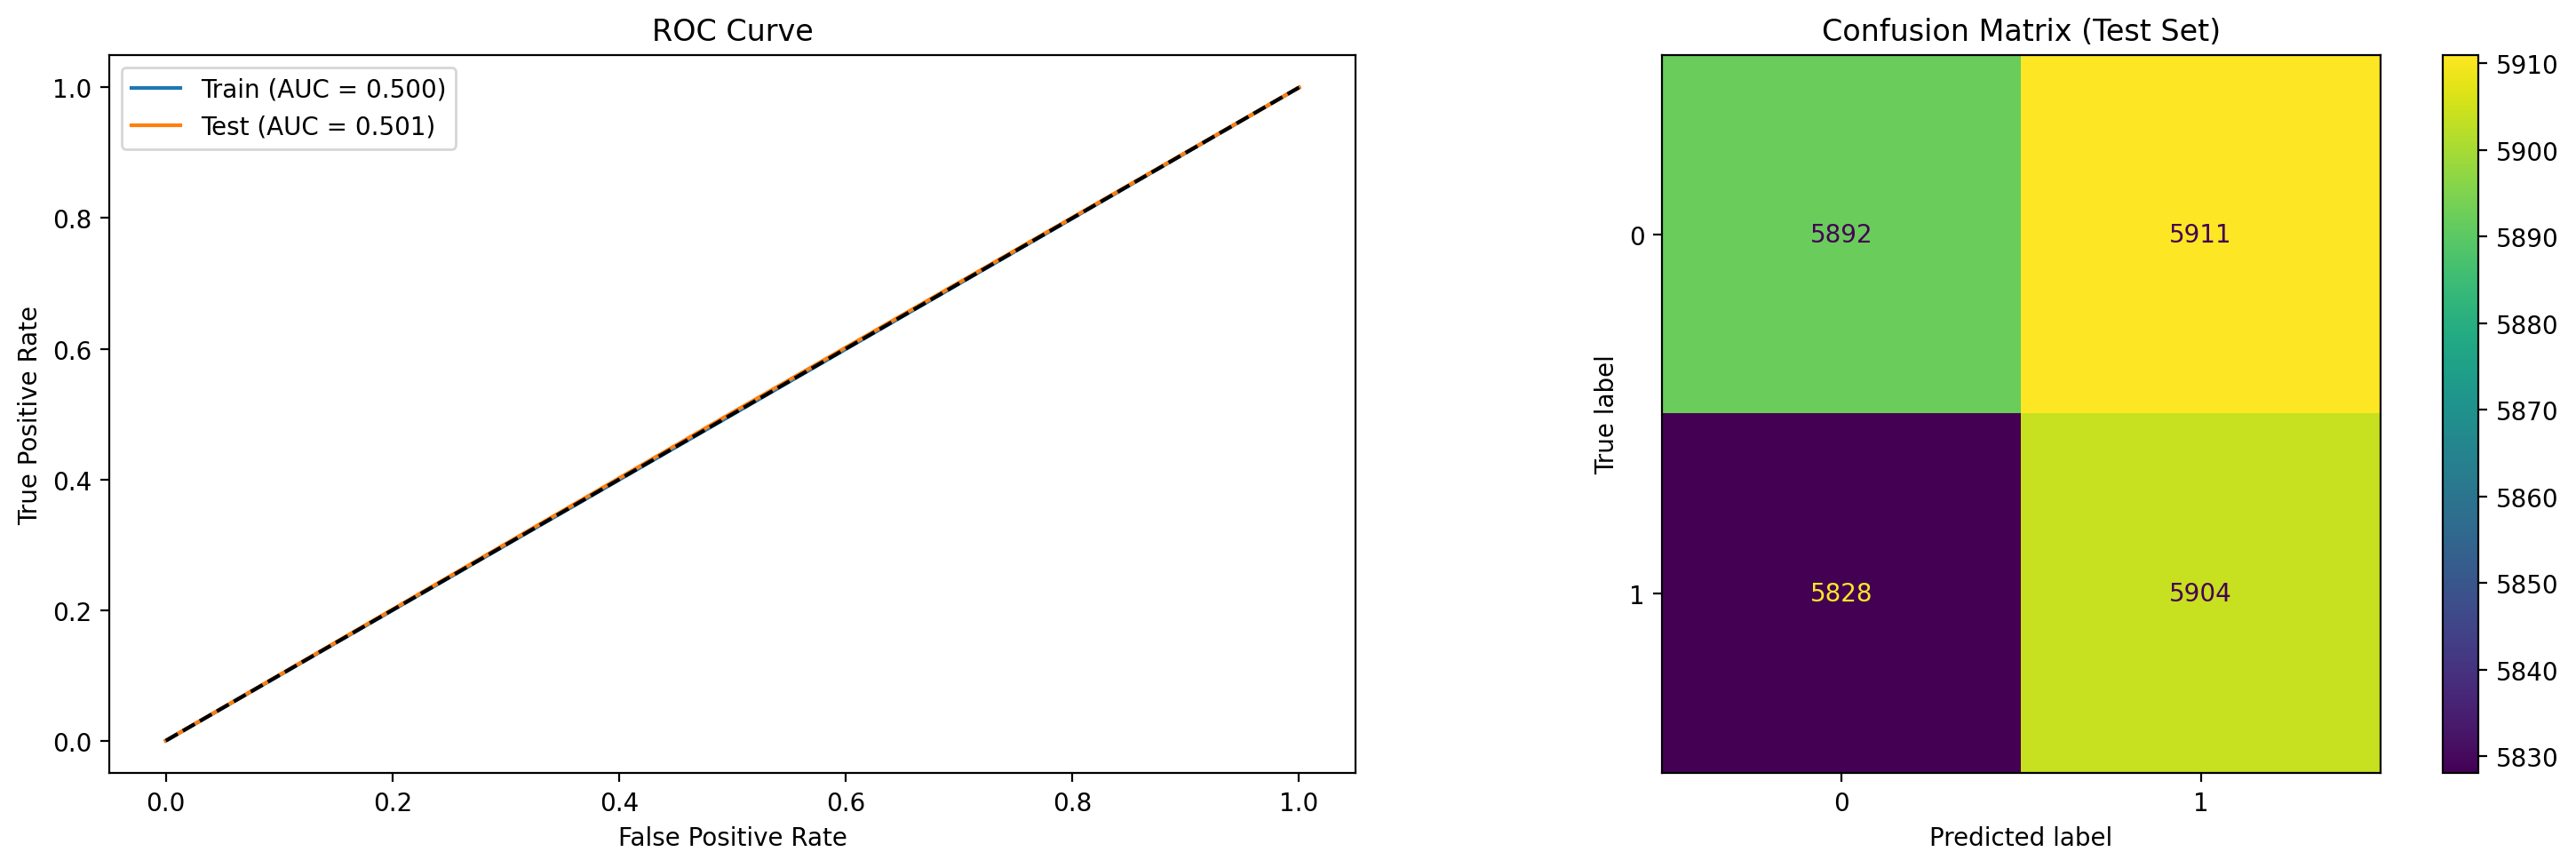

In [57]:
# DummyClassifier
model_0 = DummyClassifier(strategy='stratified', random_state=42)
model_0.fit(X_tfidf_train, y_train)

# Evaluation
evaluate_model(model_0, X_tfidf_train, y_train, X_tfidf_test, y_test)

### Modelo 1 - Logistic Regression

Model Performance Metrics:
          Train   Test
Accuracy  0.923  0.880
F1        0.924  0.880
ROC AUC   0.977  0.951


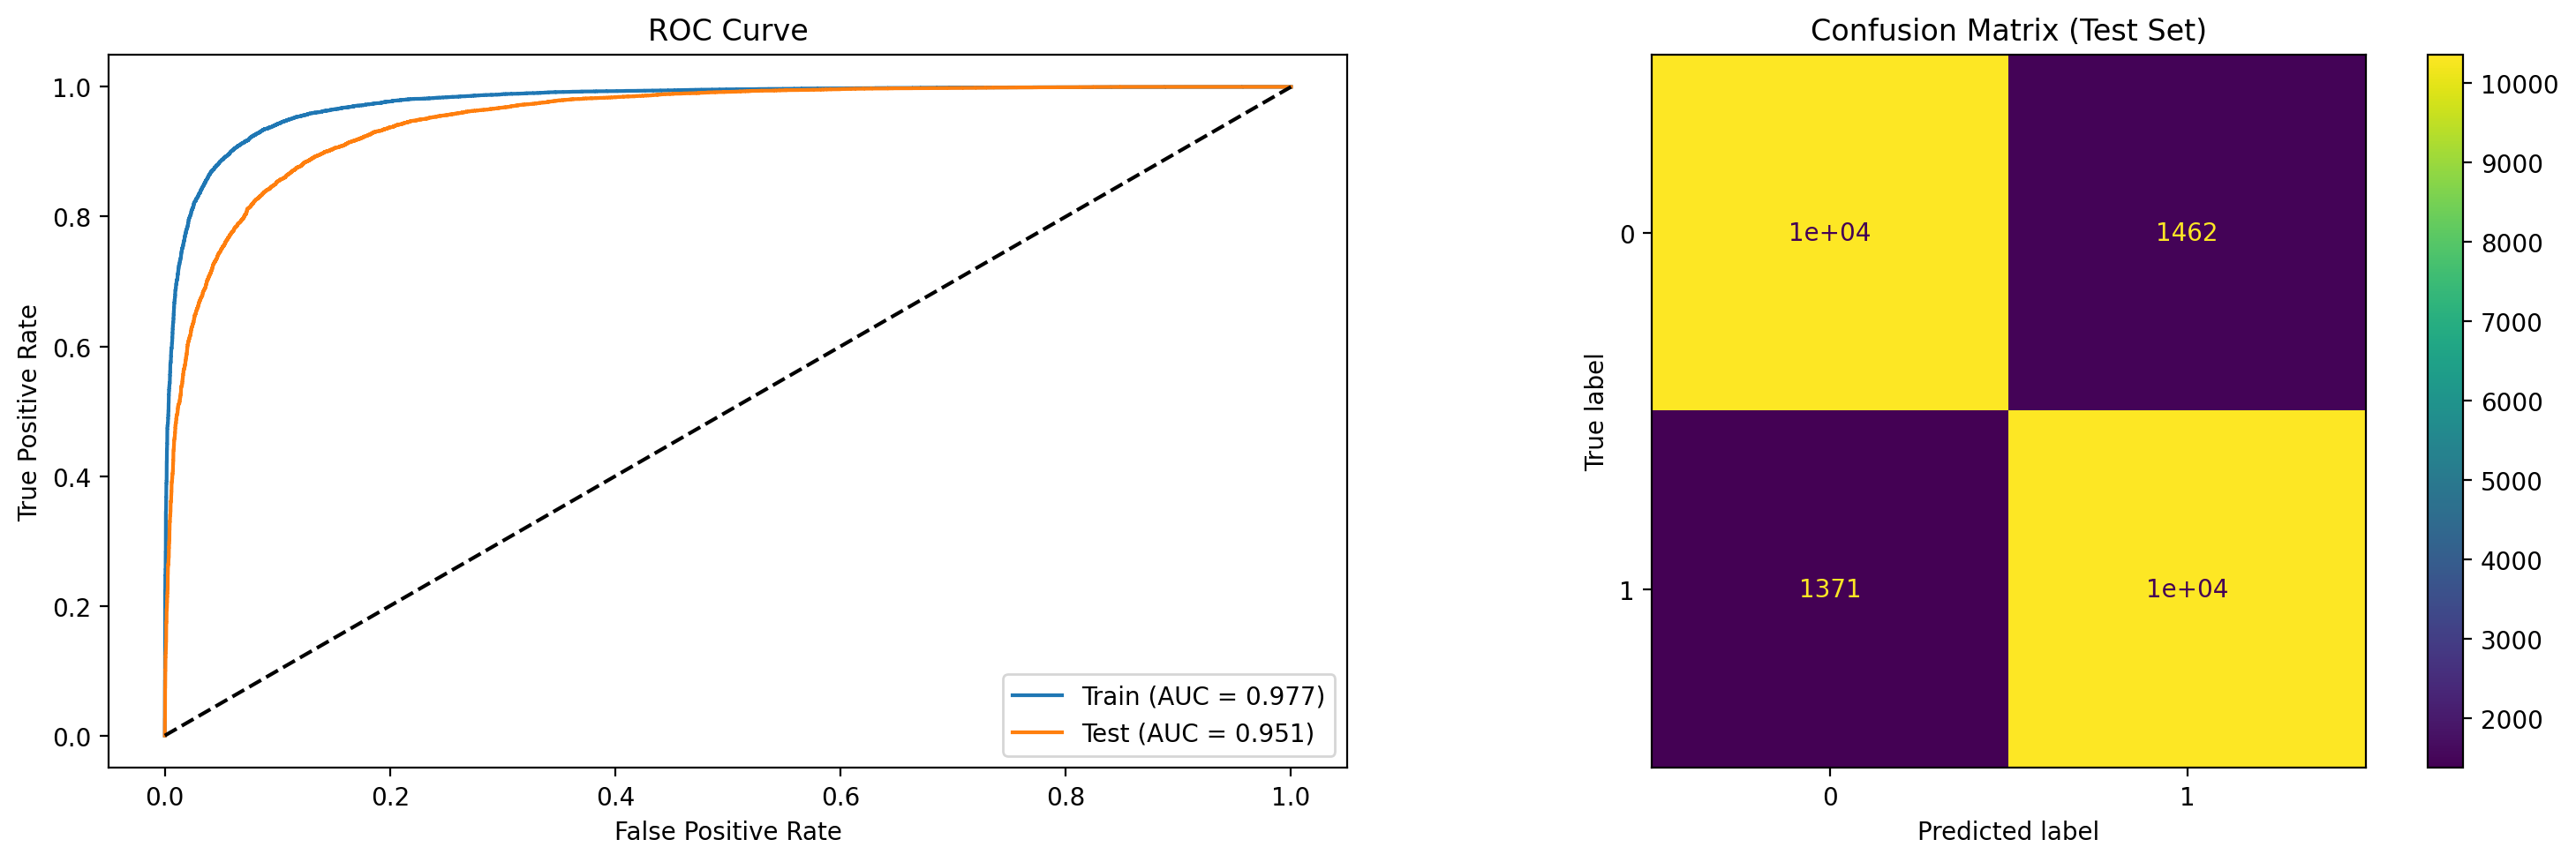

In [58]:
# LogisticRegression
model_1 = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42, max_iter=2000)
model_1.fit(X_tfidf_train, y_train)

# Evaluation
evaluate_model(model_1, X_tfidf_train, y_train, X_tfidf_test, y_test)

### Model 2 - Random Forest

Model Performance Metrics:
          Train   Test
Accuracy  0.890  0.830
F1        0.896  0.837
ROC AUC   0.965  0.914


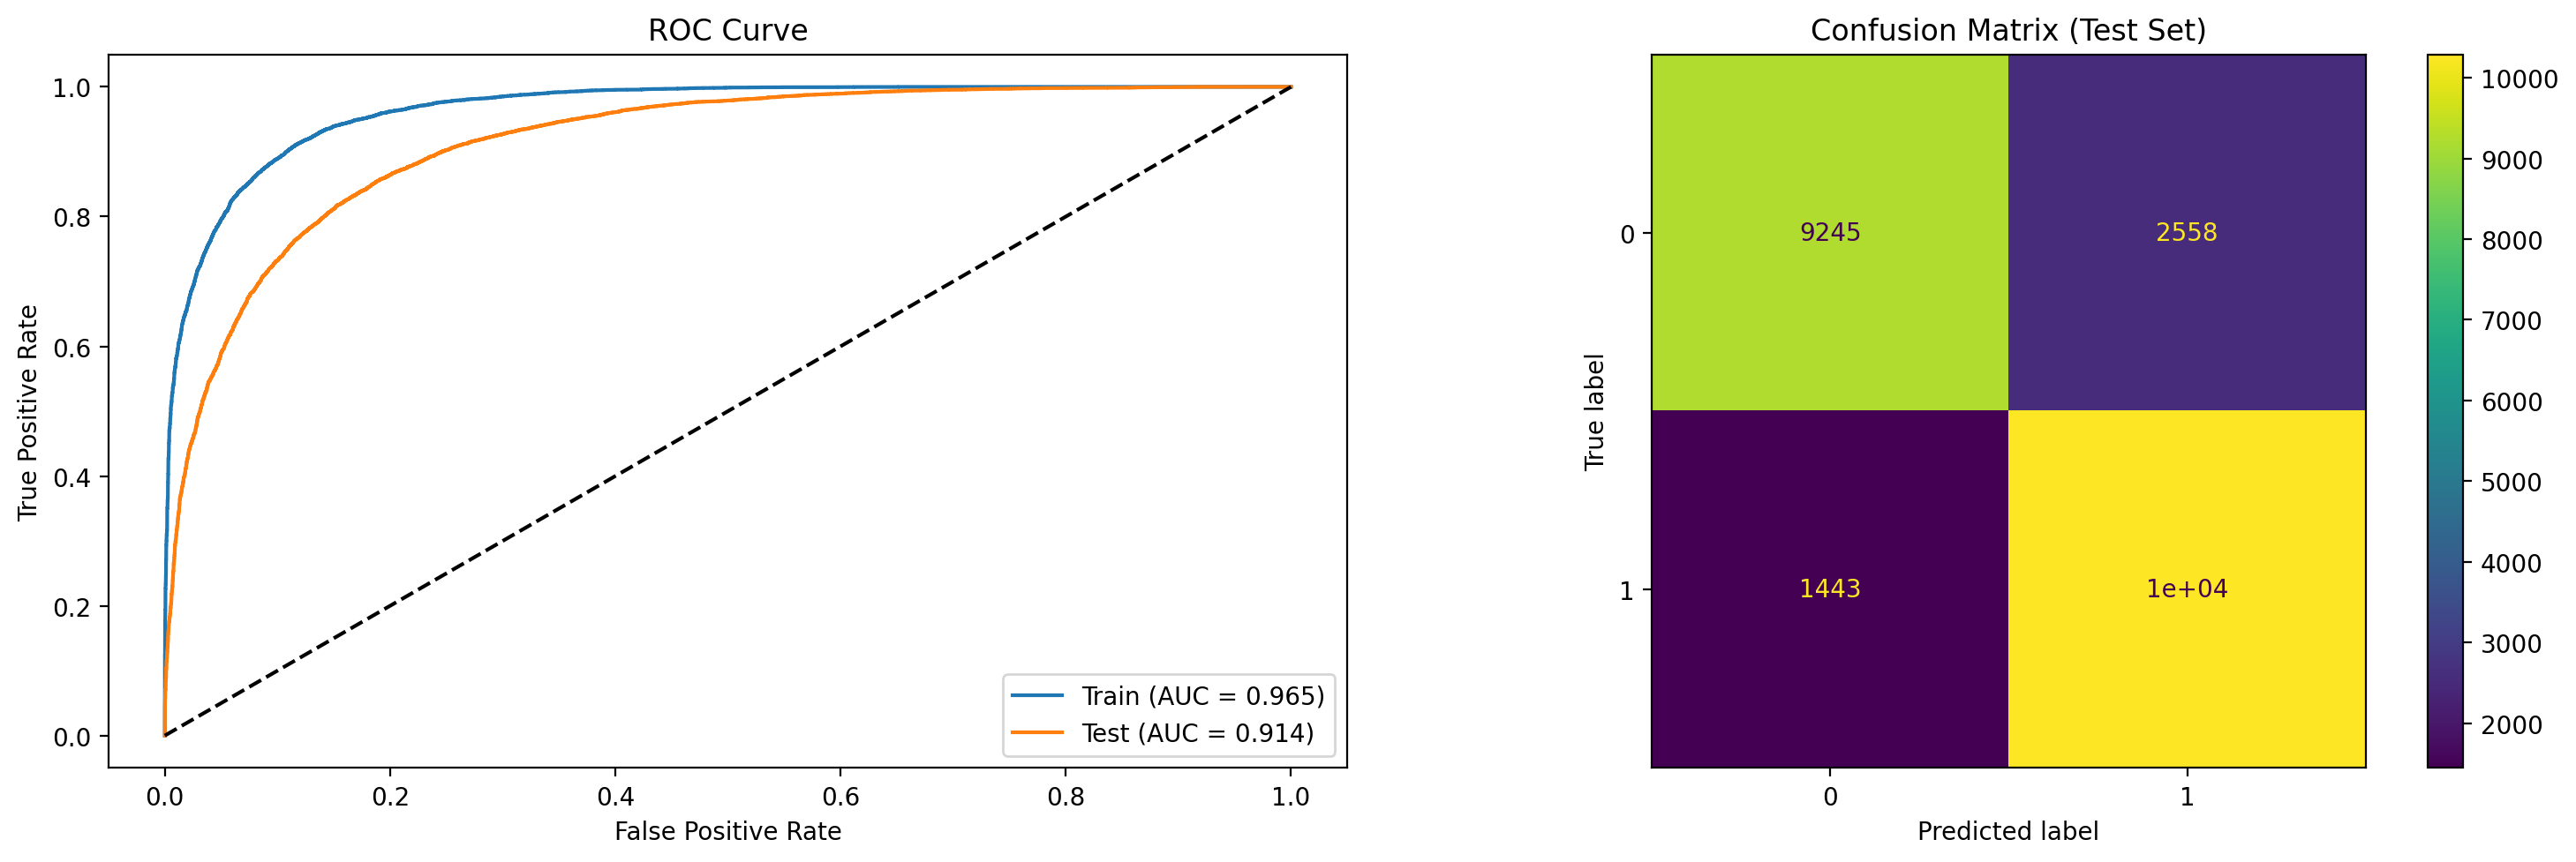

In [59]:
# RandomForestClassifier
model_2 = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, class_weight='balanced')
model_2.fit(X_tfidf_train, y_train)

# Evaluation
evaluate_model(model_2, X_tfidf_train, y_train, X_tfidf_test, y_test)


### Modelo 3 - XGBoost

Model Performance Metrics:
          Train   Test
Accuracy  0.919  0.839
F1        0.921  0.844
ROC AUC   0.979  0.923


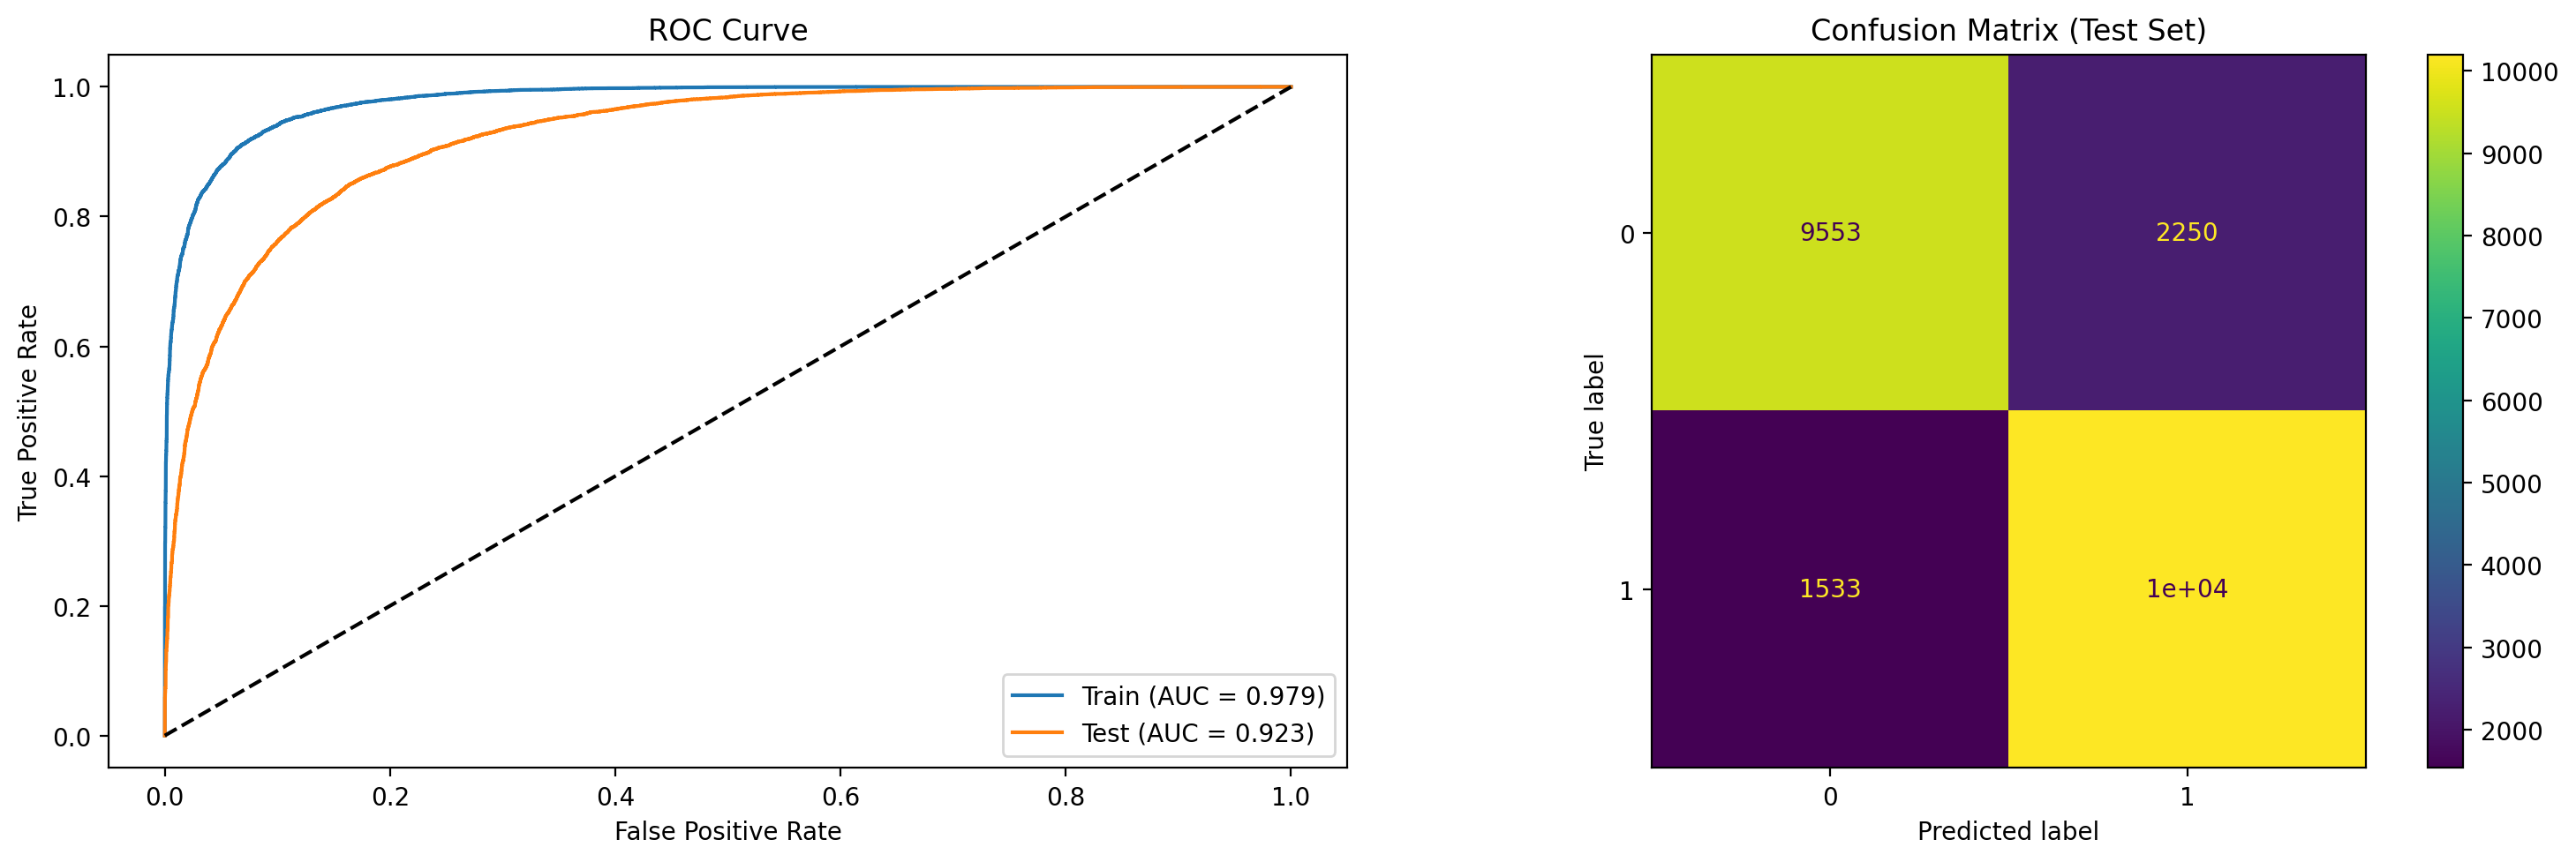

In [37]:
# XGBClassifier
model_3 = XGBClassifier(n_estimators=150, max_depth=7, random_state=42, learning_rate=0.1, eval_metric='logloss', n_jobs=-1)
model_3.fit(X_tfidf_train, y_train)

# Evaluation
evaluate_model(model_3, X_tfidf_train, y_train, X_tfidf_test, y_test)

### Modelo 4 - LGBM

Model Performance Metrics:
          Train   Test
Accuracy  0.906  0.846
F1        0.908  0.849
ROC AUC   0.970  0.928


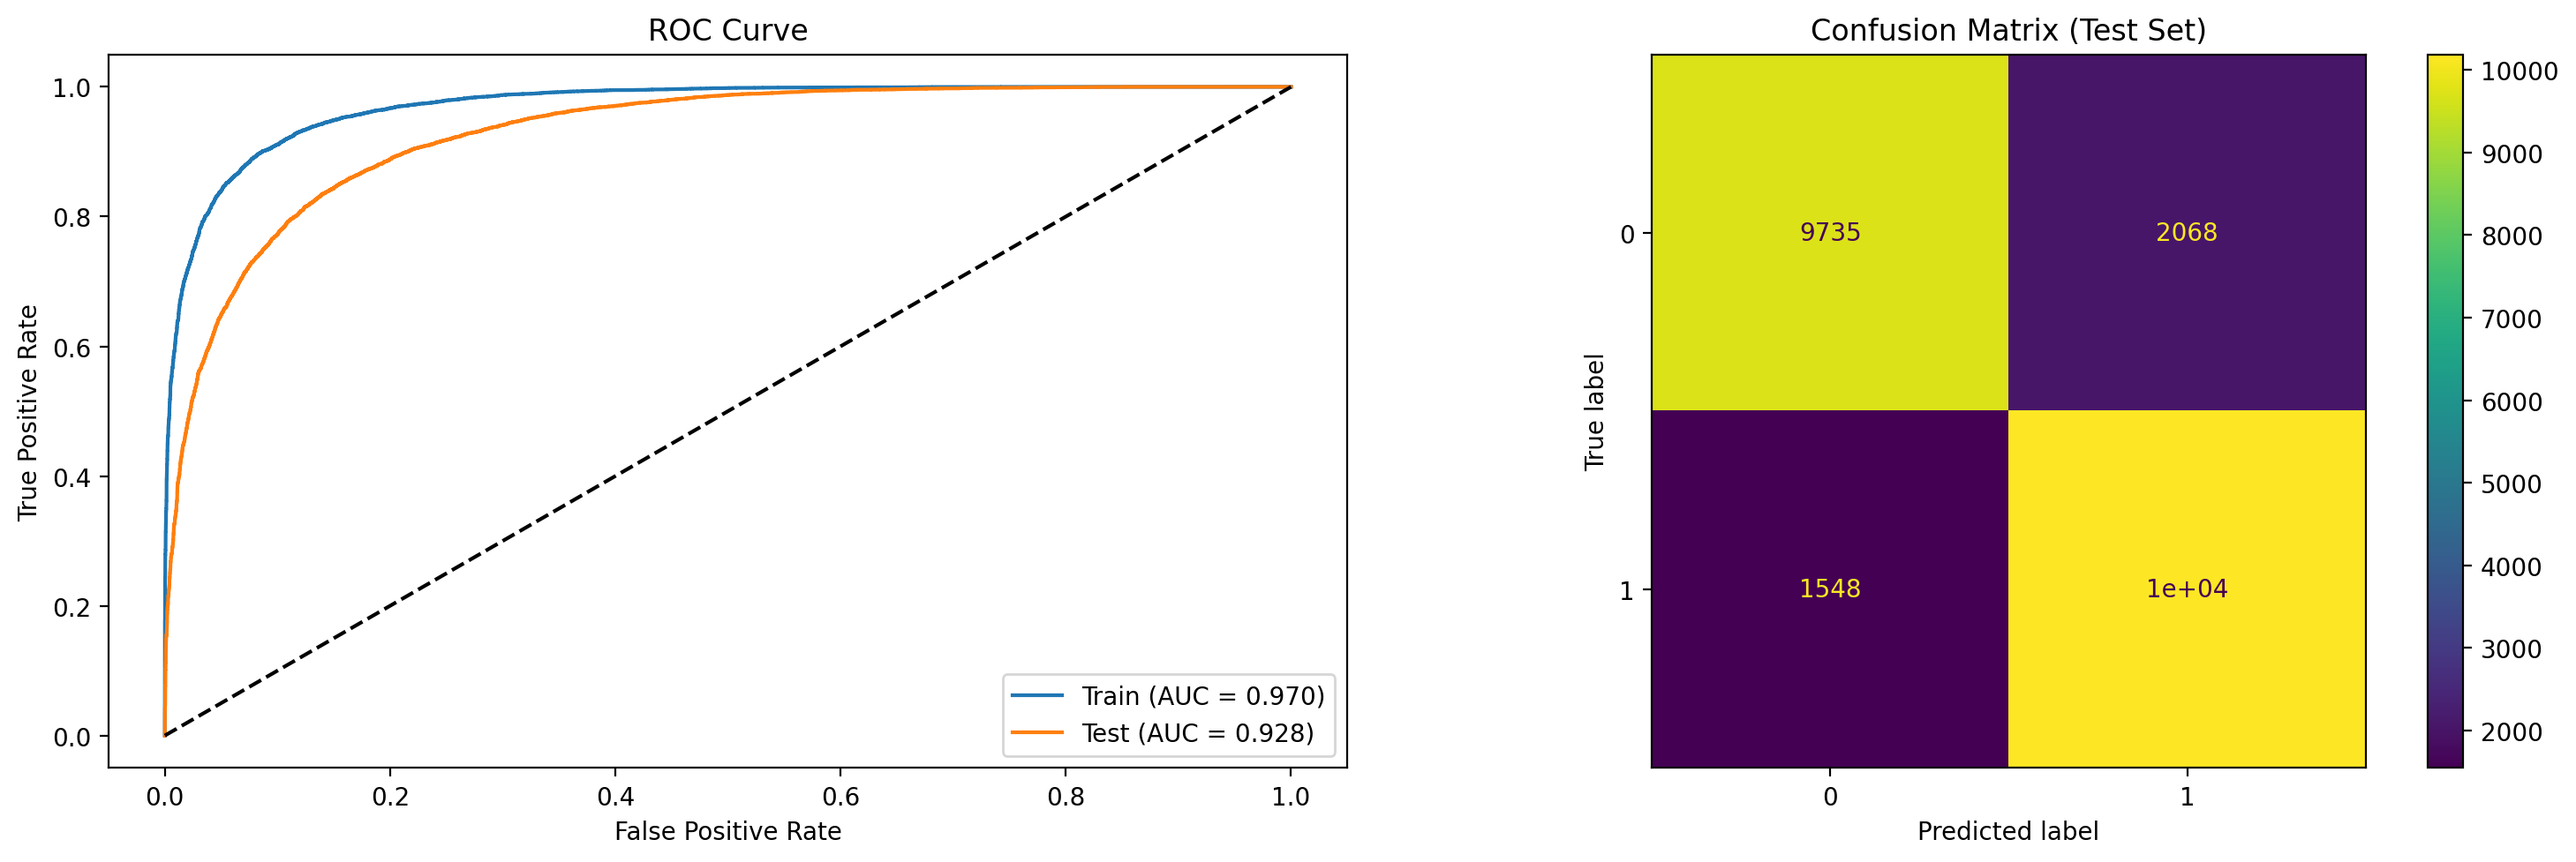

In [44]:
feature_names = tfidf.get_feature_names_out()

X_tfidf_train_LG = pd.DataFrame(X_tfidf_train.toarray(), columns=feature_names)
X_tfidf_test_LG = pd.DataFrame(X_tfidf_test.toarray(), columns=feature_names)

# LGBMClassifier
model_4 = LGBMClassifier(n_estimators=200, max_depth=15, learning_rate=0.05, num_leaves=31, subsample=0.8, random_state=42, force_row_wise=True, n_jobs=-1, verbose=-1)
model_4.fit(X_tfidf_train_LG, y_train)

# Evaluation
evaluate_model(model_4, X_tfidf_train_LG, y_train, X_tfidf_test_LG, y_test)

###  Modelo 5 - BERT

In [ ]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')

In [ ]:
def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None, disable_progress_bar=False):

    ids_list = []
    attention_mask_list = []

    # texto al id de relleno de tokens junto con sus máscaras de atención

    # <escribe tu código aquí para crear ids_list y attention_mask_list>

    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.to(device)
    if not disable_progress_bar:
        print(f'Uso del dispositivo {device}.')

    # obtener insertados en lotes

    embeddings = []

    for i in tqdm(range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar):

        ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
        # <escribe tu código aquí para crear attention_mask_batch

        with torch.no_grad():
            model.eval()
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)
        embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())

    return np.concatenate(embeddings)

In [ ]:
# ¡Atención! La ejecución de BERT para miles de textos puede llevar mucho tiempo en la CPU, al menos varias horas
train_features_9 = BERT_text_to_embeddings(df_reviews_train['review_norm'], force_device='cuda')

In [ ]:
print(df_reviews_train['review_norm'].shape)
print(train_features_9.shape)
print(train_target.shape)

In [ ]:
# si ya obtuviste los insertados, te recomendamos guardarlos para tenerlos listos si
# np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# y cargar...
# with np.load('features_9.npz') as data:
#     train_features_9 = data['train_features_9']
#     test_features_9 = data['test_features_9']

## My Reviews

In [ ]:
# puedes eliminar por completo estas reseñas y probar tus modelos en tus propias reseñas; las que se muestran a continuación son solo ejemplos

my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.'
], columns=['review'])

"""
my_reviews = pd.DataFrame([
    'Simplemente no me gustó, no es mi tipo de película.',
    'Bueno, estaba aburrido y me quedé dormido a media película.',
    'Estaba realmente fascinada con la película',
    'Hasta los actores parecían muy viejos y desinteresados, y les pagaron por estar en la película. Qué robo tan desalmado.',
    '¡No esperaba que el relanzamiento fuera tan bueno! Los escritores realmente se preocuparon por el material original',
    'La película tuvo sus altibajos, pero siento que, en general, es una película decente. Sí la volvería a ver',
    'Qué pésimo intento de comedia. Ni una sola broma tiene sentido, todos actúan de forma irritante y ruidosa, ¡ni siquiera a los niños les gustará esto!',
    'Fue muy valiente el lanzamiento en Netflix y realmente aprecio poder seguir viendo episodio tras episodio de este nuevo drama tan emocionante e inteligente.'
], columns=['review'])
"""

my_reviews['review_norm'] = ...# <escribe aquí la misma lógica de normalización que para el conjunto de datos principal>

my_reviews

### Modelo 1

In [ ]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_2.predict_proba(tfidf_vectorizer_2.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.14:  simplemente no me gustó no es mi tipo de película
0.16:  bueno estaba aburrido y me quedé dormido a media película 
0.54:  estaba realmente fascinada con la película
0.11:  hasta los actores parecían muy viejos y desinteresados y les pagaron por estar en la película qué
0.31:  no esperaba que el relanzamiento fuera tan bueno los escritores realmente se preocuparon por el material original
0.47:  la película tuvo sus altibajos pero siento que en general es una película decente sí la volvería
0.04:  qué pésimo intento de comedia ni una sola broma tiene sentido todos actúan de forma irritante y ruidosa ni siquiera a los ni
0.82:  fue muy valiente el lanzamiento en netflix realmente aprecio poder seguir viendo episodio tras epi


### Modelo 2

In [ ]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_3.predict_proba(tfidf_vectorizer_3.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

### Modelo 3

In [ ]:
texts = my_reviews['review_norm']

tfidf_vectorizer_4 = tfidf_vectorizer_3
my_reviews_pred_prob = model_4.predict_proba(tfidf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

### Modelo 4

In [ ]:
texts = my_reviews['review_norm']

my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

my_reviews_pred_prob = model_9.predict_proba(my_reviews_features_9)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

## Conclusion

# Lista de comprobación

- [x]  Abriste el notebook
- [ ]  Cargaste y preprocesaste los datos de texto para su vectorización
- [ ]  Transformaste los datos de texto en vectores
- [ ]  Entrenaste y probaste los modelos
- [ ]  Se alcanzó el umbral de la métrica
- [ ]  Colocaste todas las celdas de código en el orden de su ejecución
- [ ]  Puedes ejecutar sin errores todas las celdas de código
- [ ]  Hay conclusiones